# Train SelfTICA from scratch and transfer to the Müller–Brown committor

This tutorial demonstrates the workflow

$$
\text{Müller–Brown trajectory}
\rightarrow
\text{SelfTICA pretraining}
\rightarrow
\text{frozen latent representation}
\rightarrow
\text{linear readout}
\rightarrow
\text{standard mlcolvar Committor}.
$$

The downstream model uses the standard `Committor` class and the standard `CommittorLoss`.  
No custom `CachedLinearCommittor` is defined.

The transfer setup is:

- train SelfTICA from scratch;
- freeze the pretrained SelfTICA encoder;
- reuse the latent representation before the final TICA projection;
- train only a linear readout for the committor.

## 1. Imports

In [1]:
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

from mlcolvar.cvs import SelfTICA, Committor
from mlcolvar.data import DictModule
from mlcolvar.io import (
    load_dataframe,
    create_dataset_from_files,
)
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import (
    muller_brown_potential,
    plot_isolines_2D,
    plot_metrics,
)
from mlcolvar.cvs.committor.utils import (
    compute_committor_weights,
    initialize_committor_masses,
)
from mlcolvar.featurization.transfer import (
    TransferFeaturizer,
    TransferModel,
    export_transfer_torchscript,
)

torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

print("PyTorch:", torch.__version__)
print("Lightning:", lightning.__version__)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.


PyTorch: 2.8.0+cu128
Lightning: 2.6.1


# Part I — Train SelfTICA from scratch

## 2. Load the Müller–Brown trajectory

The SelfTICA pretraining trajectory uses the same two-dimensional coordinates `p.x` and `p.y`.

In [2]:
SELFTICA_TRAJECTORY = "data/muller-brown/unbiased/high-temp/COLVAR"

df_selftica = load_dataframe(
    [SELFTICA_TRAJECTORY],
    start=0,
    stop=10000,
    stride=5,
)

X_selftica = df_selftica.filter(
    regex="p.x|p.y"
).values

print("Trajectory frames :", len(X_selftica))
print("Input dimension   :", X_selftica.shape[1])

Trajectory frames : 1001
Input dimension   : 2


## 3. Construct time-lagged training pairs

In [3]:
SELFTICA_TRAIN_LAG = 1

selftica_dataset = create_timelagged_dataset(
    X_selftica,
    lag_time=SELFTICA_TRAIN_LAG,
)

selftica_datamodule = DictModule(
    selftica_dataset,
    lengths=[0.8, 0.2],
)

print(selftica_dataset)
print(selftica_datamodule)

DictDataset( "data": [1000, 2], "data_lag": [1000, 2], "weights": [1000], "weights_lag": [1000],
	    metadata={"data_type": descriptors } )
DictModule(dataset -> DictDataset( "data": [1000, 2], "data_lag": [1000, 2], "weights": [1000], "weights_lag": [1000],
	    metadata={"data_type": descriptors } ),
	     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=True),
	     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=True))


## 4. Initialize SelfTICA

The encoder architecture is

$$
2 \rightarrow 15 \rightarrow 15 \rightarrow 5.
$$

The five-dimensional encoder output is the representation transferred to the downstream committor task.

In [4]:
n_cvs = 1

encoder_layers = [
    2,
    15,
    15,
    5,
]

selftica_options = {
    "nn": {
        "activation": "shifted_softplus",
    }
}

selftica = SelfTICA(
    encoder_layers,
    predictor_depth=3,
    n_cvs=n_cvs,
    options=selftica_options,
)

selftica

SelfTICA(
  (loss_fn): ContrastiveLoss()
  (norm_in): Normalization(in_features=2, out_features=2, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=2, out_features=15, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=15, out_features=15, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=15, out_features=5, bias=True)
    )
  )
  (predictor): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=5, out_features=5, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=5, out_features=5, bias=True)
    )
  )
  (tica): TICA(in_features=5, out_features=1)
)

## 5. Train SelfTICA

In [ ]:
SELFTICA_EPOCHS = 5

selftica_metrics = MetricsCallback()

selftica_trainer = lightning.Trainer(
    callbacks=[selftica_metrics],
    max_epochs=SELFTICA_EPOCHS,
    logger=False,
    enable_checkpointing=False,
)

selftica_trainer.fit(
    selftica,
    selftica_datamodule,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type            | Params | Mode  | FLOPs | In sizes | Out sizes
-------------------------------------------------------------------------------------
0 | loss_fn   | ContrastiveLoss | 0      | train | 0     | ?        | ?        
1 | norm_in   | Normalization   | 0      | train | 0     | [1, 2]   | [1, 2]   
2 | nn        | FeedForward     | 365    | train | 660   | [1, 2]   | [1, 5]   
3 | predictor | FeedForward     | 60     | train | 0     | ?        | ?        
4 | tica      | TICA            | 0      | train | 0     | ?        | ?        
---------------------------------------------------------------------------------

Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 53.19it/s]                   

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 51.18it/s]


## 6. Inspect SelfTICA training

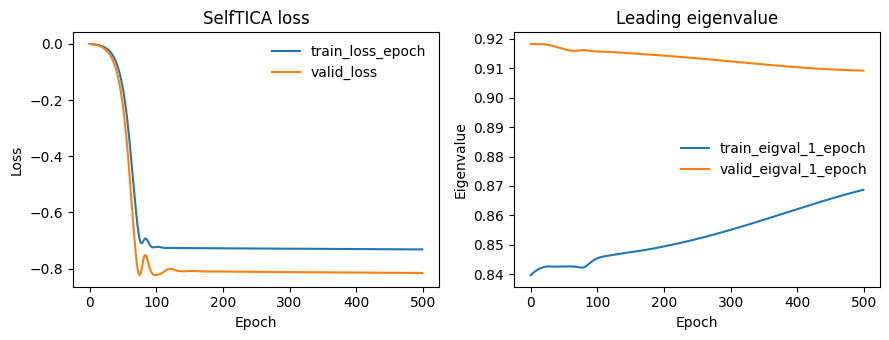

In [6]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(9, 3.5),
    sharex=True,
)

plot_metrics(
    selftica_metrics.metrics,
    keys=[
        "train_loss_epoch",
        "valid_loss",
    ],
    ax=ax1,
    yscale="linear",
)

ax1.set_title("SelfTICA loss")
ax1.set_ylabel("Loss")

plot_metrics(
    selftica_metrics.metrics,
    keys=[
        "train_eigval_1_epoch",
        "valid_eigval_1_epoch",
    ],
    ax=ax2,
    yscale="linear",
)

ax2.set_title("Leading eigenvalue")
ax2.set_ylabel("Eigenvalue")

for ax in (ax1, ax2):
    ax.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

## 7. Visualize the trained SelfTICA CV

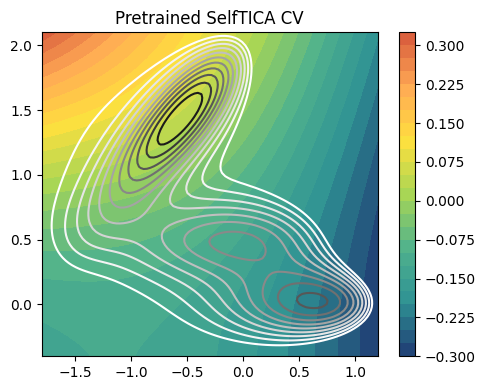

In [7]:
selftica.eval()

fig, ax = plt.subplots(figsize=(5, 4))

plot_isolines_2D(
    muller_brown_potential,
    levels=np.linspace(0, 24, 12),
    mode="contour",
    ax=ax,
)

plot_isolines_2D(
    selftica,
    component=0,
    levels=25,
    ax=ax,
)

ax.set_title("Pretrained SelfTICA CV")

plt.tight_layout()
plt.show()

# Part II — Transfer the frozen SelfTICA representation

## 8. Build the frozen latent featurizer

`TransferFeaturizer(..., mode="latent")` reuses the pretrained SelfTICA encoder before the final TICA projection.

With `freeze=True`, SelfTICA parameters are not optimized during committor training, while gradients with respect to the original input remain available.


In [8]:
selftica.eval()

featurizer = TransferFeaturizer(
    model=selftica,
    mode="latent",
    freeze=True,
)

print("Input features :", featurizer.in_features)
print("Latent features:", featurizer.out_features)


Input features : 2
Latent features: 5


## 9. Inspect the latent representation

In [9]:
x_test = torch.as_tensor(
    X_selftica[:32],
    dtype=torch.get_default_dtype(),
)

with torch.no_grad():
    h_test = featurizer(x_test)

print("Input shape :", tuple(x_test.shape))
print("Latent shape:", tuple(h_test.shape))

Input shape : (32, 2)
Latent shape: (32, 5)


## 10. Add a linear task-specific readout

The transferred representation is passed to a `TransferModel` with no hidden layers, giving a linear probe:

$$
z(\mathbf{x})
=
\mathbf{w}^{T}
\phi_\theta(\mathbf{x})
+b.
$$

Only the task-specific linear readout parameters are trainable.


In [10]:
transfer_model = TransferModel(
    featurizer=featurizer,
    n_out=1,
    hidden_layers=(),
)

transfer_model


_TensorTransferModel(
  (nn): Sequential(
    (0): Linear(in_features=5, out_features=1, bias=True)
  )
  (featurizer): _TensorLatentFeaturizer(
    (model): SelfTICA(
      (loss_fn): ContrastiveLoss()
      (norm_in): Normalization(in_features=2, out_features=2, mode=mean_std)
      (nn): FeedForward(
        (nn): Sequential(
          (0): Linear(in_features=2, out_features=15, bias=True)
          (1): Shifted_Softplus(beta=1, threshold=20)
          (2): Linear(in_features=15, out_features=15, bias=True)
          (3): Shifted_Softplus(beta=1, threshold=20)
          (4): Linear(in_features=15, out_features=5, bias=True)
        )
      )
      (predictor): FeedForward(
        (nn): Sequential(
          (0): Linear(in_features=5, out_features=5, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=5, out_features=5, bias=True)
        )
      )
      (tica): TICA(in_features=5, out_features=1)
    )
  )
)

## 11. Check trainable and frozen parameters

In [11]:
n_trainable = 0
n_frozen = 0

for name, parameter in transfer_model.named_parameters():
    status = (
        "trainable"
        if parameter.requires_grad
        else "frozen"
    )

    print(
        f"{status:10s} | "
        f"{name:70s} | "
        f"{tuple(parameter.shape)}"
    )

    if parameter.requires_grad:
        n_trainable += parameter.numel()
    else:
        n_frozen += parameter.numel()

print()
print("Trainable parameters:", n_trainable)
print("Frozen parameters   :", n_frozen)

trainable  | nn.0.weight                                                            | (1, 5)
trainable  | nn.0.bias                                                              | (1,)
frozen     | featurizer.model.nn.nn.0.weight                                        | (15, 2)
frozen     | featurizer.model.nn.nn.0.bias                                          | (15,)
frozen     | featurizer.model.nn.nn.2.weight                                        | (15, 15)
frozen     | featurizer.model.nn.nn.2.bias                                          | (15,)
frozen     | featurizer.model.nn.nn.4.weight                                        | (5, 15)
frozen     | featurizer.model.nn.nn.4.bias                                          | (5,)
frozen     | featurizer.model.predictor.nn.0.weight                                 | (5, 5)
frozen     | featurizer.model.predictor.nn.0.bias                                   | (5,)
frozen     | featurizer.model.predictor.nn.2.weight                       

## 12. Verify gradients with respect to the input

Freezing SelfTICA parameters does not detach the encoder from its input.  
Therefore the committor loss can still evaluate derivatives with respect to the original coordinates.

In [12]:
x_grad = torch.randn(
    8,
    featurizer.in_features,
    requires_grad=True,
)

z_test = transfer_model(
    x_grad
).sum()

grad_x = torch.autograd.grad(
    z_test,
    x_grad,
    create_graph=True,
)[0]

print("Gradient wrt input exists:", grad_x is not None)
print("Gradient shape           :", tuple(grad_x.shape))
print("Gradient finite          :", bool(torch.isfinite(grad_x).all()))

Gradient wrt input exists: True
Gradient shape           : (8, 2)
Gradient finite          : True


# Part III — Prepare the Müller–Brown committor dataset

The downstream dataset follows the public Müller–Brown data used in the mlcolvar committor tutorial.

It contains:

- two unbiased A/B boundary-state trajectories;
- two biased trajectories from iteration 0;
- two biased trajectories from iteration 1.

In [13]:
T = 1.0
kb = 1.0
beta = 1.0 / (kb * T)

print("Beta:", beta)

Beta: 1.0


## 13. Public trajectory files

In [14]:
filenames = [
    (
        "https://raw.githubusercontent.com/"
        "EnricoTrizio/committor_2.0/"
        "refs/heads/main/muller/"
        "unbiased_sims/A/COLVAR"
    ),
    (
        "https://raw.githubusercontent.com/"
        "EnricoTrizio/committor_2.0/"
        "refs/heads/main/muller/"
        "unbiased_sims/B/COLVAR"
    ),
    (
        "https://raw.githubusercontent.com/"
        "EnricoTrizio/committor_2.0/"
        "refs/heads/main/muller/"
        "biased_sims/iter_0/A/COLVAR"
    ),
    (
        "https://raw.githubusercontent.com/"
        "EnricoTrizio/committor_2.0/"
        "refs/heads/main/muller/"
        "biased_sims/iter_0/B/COLVAR"
    ),
    (
        "https://raw.githubusercontent.com/"
        "EnricoTrizio/committor_2.0/"
        "refs/heads/main/muller/"
        "biased_sims/iter_1/A/COLVAR"
    ),
    (
        "https://raw.githubusercontent.com/"
        "EnricoTrizio/committor_2.0/"
        "refs/heads/main/muller/"
        "biased_sims/iter_1/B/COLVAR"
    ),
]

load_args = [
    {
        "start": 0,
        "stop": 2000,
        "stride": 1,
    },
    {
        "start": 0,
        "stop": 2000,
        "stride": 1,
    },
    {
        "start": 1000,
        "stop": 10000,
        "stride": 1,
    },
    {
        "start": 1000,
        "stop": 10000,
        "stride": 1,
    },
    {
        "start": 1000,
        "stop": 10000,
        "stride": 1,
    },
    {
        "start": 1000,
        "stop": 10000,
        "stride": 1,
    },
]

## 14. Load and label the committor data

In [15]:
committor_dataset, committor_dataframe = create_dataset_from_files(
    file_names=filenames,
    create_labels=True,
    filter_args={
        "regex": "p.x|p.y",
    },
    return_dataframe=True,
    load_args=load_args,
    verbose=True,
)

Class 0 dataframe shape:  (2000, 13)
Class 1 dataframe shape:  (2000, 13)
Class 2 dataframe shape:  (9000, 24)
Class 3 dataframe shape:  (9000, 24)
Class 4 dataframe shape:  (9000, 24)
Class 5 dataframe shape:  (9000, 24)

 - Loaded dataframe (40000, 27): ['time', 'p.x', 'p.y', 'p.z', 'ene', 'pot.bias', 'pot.ene_bias', 'lwall.bias', 'lwall.force2', 'uwall.bias', 'uwall.force2', 'walker', 'labels', 'mueller', 'potential.bias', 'potential.mueller_bias', 'z.node-0', 'z.bias-0', 'q', 'bias', '@8.bias', '@8.bias_bias', 'opes.bias', 'opes.rct', 'opes.zed', 'opes.neff', 'opes.nker']
 - Descriptors (40000, 2): ['p.x', 'p.y']


/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/io/colvar.py:292: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  dictionary["labels"] = torch.Tensor(df["labels"].values)


## 15. Compute statistical weights

In [16]:
committor_dataframe = committor_dataframe.fillna(
    {
        "opes.bias": 0,
    }
)

committor_dataframe = committor_dataframe.fillna(
    {
        "bias": 0,
    }
)

bias = torch.tensor(
    committor_dataframe["opes.bias"].values
    +
    committor_dataframe["bias"].values,
    dtype=torch.get_default_dtype(),
)

committor_dataset = compute_committor_weights(
    committor_dataset,
    bias,
    [
        0,
        1,
        2,
        3,
        4,
        5,
    ],
    beta,
)

committor_datamodule = DictModule(
    committor_dataset,
    lengths=[1],
)

x_committor = committor_dataset["data"]

assert x_committor.ndim == 2
assert x_committor.shape[1] == featurizer.in_features == 2

print("Committor samples:", len(committor_dataset))
print("Input dimension:", x_committor.shape[1])
print(committor_dataset)

Committor samples: 40000
Input dimension: 2
DictDataset( "data": [40000, 2], "labels": [40000], "weights": [40000],
	    metadata={"data_type": descriptors } )


## 16. Visualize labels and weights

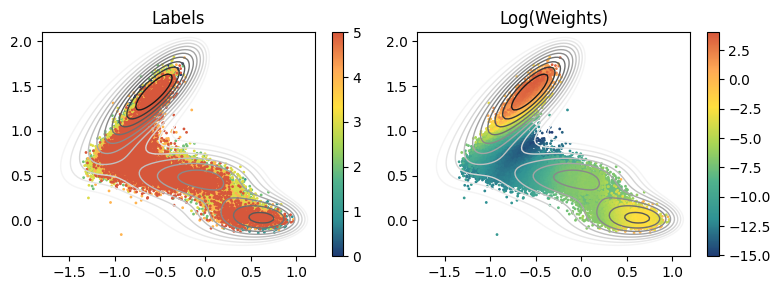

In [17]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(8, 3),
)

ax = axs[0]
ax.set_title("Labels")

plot_isolines_2D(
    muller_brown_potential,
    levels=np.linspace(
        0,
        24,
        12,
    ),
    ax=ax,
    max_value=24,
    colorbar=False,
    mode="contour",
    linewidths=1,
)

cp = ax.scatter(
    committor_dataset["data"][:, 0],
    committor_dataset["data"][:, 1],
    c=committor_dataset["labels"],
    s=1,
    cmap="fessa",
)

plt.colorbar(cp, ax=ax)

ax = axs[1]
ax.set_title("Log(Weights)")

plot_isolines_2D(
    muller_brown_potential,
    levels=np.linspace(
        0,
        24,
        12,
    ),
    ax=ax,
    max_value=24,
    colorbar=False,
    mode="contour",
    linewidths=1,
)

cp = ax.scatter(
    committor_dataset["data"][:, 0],
    committor_dataset["data"][:, 1],
    c=torch.log(
        committor_dataset["weights"]
    ),
    s=1,
    cmap="fessa",
)

plt.colorbar(cp, ax=ax)

plt.tight_layout()
plt.show()

# Part IV — Standard mlcolvar Committor

The transferred model is passed directly to the standard `Committor`.

The architecture is

$$
(x,y)
\rightarrow
\text{frozen SelfTICA encoder}
\rightarrow
\text{5D latent representation}
\rightarrow
\text{linear readout}
\rightarrow
z
\rightarrow
\sigma
\rightarrow
q.
$$

No custom committor class or custom committor loss is used.

## 17. Initialize the standard Committor

In [18]:
atomic_masses = initialize_committor_masses(
    atom_types=[0],
    masses=[1],
)

lr_scheduler = torch.optim.lr_scheduler.ExponentialLR

committor_options = {
    "optimizer": {
        "lr": 1e-3,
        "weight_decay": 1e-5,
    },
    "lr_scheduler": {
        "scheduler": lr_scheduler,
        "gamma": 0.99999,
    },
}

committor = Committor(
    model=transfer_model,
    atomic_masses=atomic_masses,
    alpha=1e-1,
    delta_f=0,
    n_dim=2,
    norm_in=False,
    options=committor_options,
)

committor

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


Committor(
  (loss_fn): CommittorLoss()
  (nn): _TensorTransferModel(
    (nn): Sequential(
      (0): Linear(in_features=5, out_features=1, bias=True)
    )
    (featurizer): _TensorLatentFeaturizer(
      (model): SelfTICA(
        (loss_fn): ContrastiveLoss()
        (norm_in): Normalization(in_features=2, out_features=2, mode=mean_std)
        (nn): FeedForward(
          (nn): Sequential(
            (0): Linear(in_features=2, out_features=15, bias=True)
            (1): Shifted_Softplus(beta=1, threshold=20)
            (2): Linear(in_features=15, out_features=15, bias=True)
            (3): Shifted_Softplus(beta=1, threshold=20)
            (4): Linear(in_features=15, out_features=5, bias=True)
          )
        )
        (predictor): FeedForward(
          (nn): Sequential(
            (0): Linear(in_features=5, out_features=5, bias=True)
            (1): ReLU(inplace=True)
            (2): Linear(in_features=5, out_features=5, bias=True)
          )
        )
        (tica):

## 18. Verify that only the linear readout is trainable

In [19]:
print(
    "\nParameters used during committor training:\n"
)

for name, parameter in committor.named_parameters():
    print(
        f"{'TRAIN' if parameter.requires_grad else 'FROZEN':8s}"
        f"  {name:70s}"
        f"  {tuple(parameter.shape)}"
    )

print()

print(
    "Total trainable parameters:",
    sum(
        p.numel()
        for p in committor.parameters()
        if p.requires_grad
    ),
)


Parameters used during committor training:

TRAIN     nn.nn.0.weight                                                          (1, 5)
TRAIN     nn.nn.0.bias                                                            (1,)
FROZEN    nn.featurizer.model.nn.nn.0.weight                                      (15, 2)
FROZEN    nn.featurizer.model.nn.nn.0.bias                                        (15,)
FROZEN    nn.featurizer.model.nn.nn.2.weight                                      (15, 15)
FROZEN    nn.featurizer.model.nn.nn.2.bias                                        (15,)
FROZEN    nn.featurizer.model.nn.nn.4.weight                                      (5, 15)
FROZEN    nn.featurizer.model.nn.nn.4.bias                                        (5,)
FROZEN    nn.featurizer.model.predictor.nn.0.weight                               (5, 5)
FROZEN    nn.featurizer.model.predictor.nn.0.bias                                 (5,)
FROZEN    nn.featurizer.model.predictor.nn.2.weight                  

## 19. Train the committor

In [ ]:
COMMITTOR_EPOCHS = 5

committor_metrics = MetricsCallback()

committor_trainer = lightning.Trainer(
    callbacks=[
        committor_metrics,
    ],
    max_epochs=COMMITTOR_EPOCHS,
    logger=False,
    enable_checkpointing=False,
    limit_val_batches=0,
    num_sanity_val_steps=0,
)

committor_trainer.fit(
    committor,
    committor_datamodule,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                 | Params | Mode  | FLOPs | In sizes | Out sizes
----------------------------------------------------------------------------------------
0 | loss_fn | CommittorLoss        | 0      | train | 0     | ?        | ?        
1 | nn      | _TensorTransferModel | 431    | train | 670   | [1, 2]   | [1, 1]   
2 | sigmoid | Custom_Sigmoid       | 0      | train | 0     | [1, 1]   | [1, 1]   
----------------------------------------------------------------------------------------
6         Trainable params
425       Non-trainable params
431       Total params
0.002     Total estimated model params size (MB)
6      

Epoch 49999: 100%|██████████| 1/1 [00:00<00:00, 28.24it/s]

`Trainer.fit` stopped: `max_epochs=50000` reached.


Epoch 49999: 100%|██████████| 1/1 [00:00<00:00, 27.51it/s]


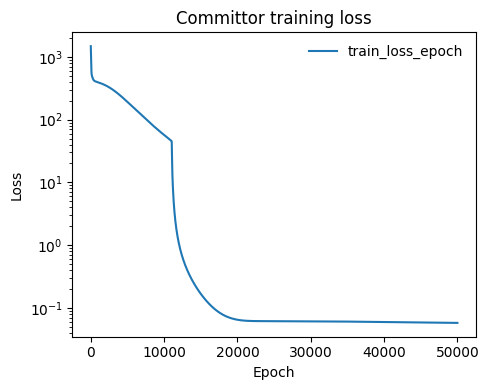

In [21]:
# Plot committor training loss

fig, ax = plt.subplots(figsize=(5, 4))

plot_metrics(
    committor_metrics.metrics,
    keys=["train_loss_epoch"],
    ax=ax,
    yscale="log",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Committor training loss")

plt.tight_layout()
plt.show()

# Part V — Evaluation

The transfer model produces the non-activated coordinate $z$, while the standard `Committor` returns

$$
q(\mathbf{x})=\sigma(z).
$$

## 20. Evaluate $z$ and $q$

In [22]:
committor.eval()
transfer_model.eval()

with torch.no_grad():
    z = transfer_model(
        x_committor
    )

    q = committor(
        x_committor
    )

print("z shape:", tuple(z.shape))
print("q shape:", tuple(q.shape))
print("z range:", float(z.min()), float(z.max()))
print("q range:", float(q.min()), float(q.max()))

z shape: (40000, 1)
q shape: (40000, 1)
z range: -5.94400208130672 12.629326108213228
q range: 1.80159878041267e-08 1.0


## 21. Identify the transition-state region

Configurations with

$$
q(\mathbf{x}) \approx 0.5
$$

are candidates for the transition-state ensemble.

In [23]:
q_flat = q.reshape(-1)

transition_mask = (
    (q_flat > 0.45)
    &
    (q_flat < 0.55)
)

transition_configs = x_committor[
    transition_mask
]

print("Total configurations:", len(x_committor))
print("q in [0.45, 0.55]:", len(transition_configs))

Total configurations: 40000
q in [0.45, 0.55]: 399


## 22. Plot the transferred committor

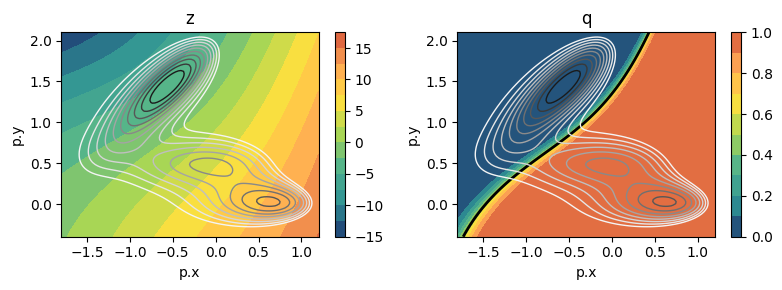

In [24]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(8, 3),
)

# z
ax = axs[0]
ax.set_title("z")

plot_isolines_2D(
    transfer_model,
    ax=ax,
    colorbar=True,
)

plot_isolines_2D(
    muller_brown_potential,
    levels=np.linspace(
        0,
        24,
        12,
    ),
    ax=ax,
    max_value=24,
    colorbar=False,
    mode="contour",
    linewidths=1,
)

ax.set_xlabel("p.x")
ax.set_ylabel("p.y")

# q
ax = axs[1]
ax.set_title("q")

plot_isolines_2D(
    committor,
    ax=ax,
    colorbar=True,
    levels=np.linspace(
        0,
        1,
        11,
    ),
)

plot_isolines_2D(
    committor,
    ax=ax,
    levels=[0.5],
    mode="contour",
    linewidths=2,
)

plot_isolines_2D(
    muller_brown_potential,
    levels=np.linspace(
        0,
        24,
        12,
    ),
    ax=ax,
    max_value=24,
    colorbar=False,
    mode="contour",
    linewidths=1,
)

ax.set_xlabel("p.x")
ax.set_ylabel("p.y")

plt.tight_layout()
plt.show()

# Part VI — Export

## 23. Export the transferred models

The transfer model is exported with `export_transfer_torchscript`, which reconstructs the complete raw-input inference path from the frozen featurizer and trained readout.

The full committor is exported separately through the standard `Committor.to_torchscript()` interface.


In [25]:
# ============================================================
# Export trained SelfTICA-transfer committor
# ============================================================

committor.eval()
transfer_model.eval()

example_input = x_committor[:1].detach().cpu()

# ------------------------------------------------------------
# 1. Export z model
#    SelfTICA latent representation + trained linear readout
# ------------------------------------------------------------

export_transfer_torchscript(
    model=transfer_model,
    path="selftica_transfer_z.pt",
    example_input=example_input,
    dtype=torch.get_default_dtype(),
)

# ------------------------------------------------------------
# 2. Export q model
#    Full standard mlcolvar Committor
# ------------------------------------------------------------

committor = committor.cpu()

committor.to_torchscript(
    file_path="selftica_transfer_q.pt",
    method="trace",
    example_inputs=example_input,
)

print("Saved:")
print("  selftica_transfer_z.pt")
print("  selftica_transfer_q.pt")


Saved:
  selftica_transfer_z.pt
  selftica_transfer_q.pt


/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/featurization/transfer/featurizers.py:304: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-1] != self.in_features:
/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/featurization/transfer/featurizers.py:318: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if output.shape[-1] != self.out_features:
/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/featurization/transfer/readouts.py:125: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We 